# 00 — Prepare common analysis inputs

This notebook centralizes the **stable inputs** used by all later cleaned GLM notebooks.

It prepares:

- final participant lists,
- pre/post viewing file availability,
- pre/post image identity matching,
- image labels parsed from filenames: old/new, relevance, object category, episode, checkpoint index,
- checkpoint-tertile labels for future early/middle/late encoding analyses,
- common QC tables and a restart manifest.

The important filename rule is:

```text
viking_4_e2_2_r_h_v4_old
        ^^ ^
        || |
        || checkpoint index = 2, out of 16
        episode = e2
```

More generally:

```text
<theme>_<item>_e<episode>_<checkpoint>_<r/nr>_<h/o>_v<version>_<old/new>
```


In [1]:
# ============================================================
# 1. Setup
# ============================================================

from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import nibabel as nib

from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)

PROJECT_ROOT = Path("/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project")
DATA_DIR = PROJECT_ROOT / "data"
BIDS_DIR = DATA_DIR / "bids_ackbar"
FMRIPREP_DIR = DATA_DIR / "fmriprep_output"
SRC_DIR = PROJECT_ROOT / "src"

# Validated inputs from previous analyses
MEMORY_QUALITY_ANALYSIS_NAME = "memory_quality_post_viewing_parametric"
MEMORY_QUALITY_TABLE_DIR = DATA_DIR / "processed" / "glm" / MEMORY_QUALITY_ANALYSIS_NAME / "tables"

SPATIAL_ONLY_ANALYSIS_NAME = "spatial_accuracy_only_post_viewing_parametric"
SPATIAL_ONLY_TABLE_DIR = DATA_DIR / "processed" / "glm" / SPATIAL_ONLY_ANALYSIS_NAME / "tables"

# Common-output folder used by all later cleaned notebooks
COMMON_DIR = DATA_DIR / "processed" / "common_inputs"
COMMON_TABLE_DIR = COMMON_DIR / "tables"
COMMON_QC_DIR = COMMON_DIR / "qc"
COMMON_MANIFEST_DIR = COMMON_DIR / "restart"

for path in [COMMON_DIR, COMMON_TABLE_DIR, COMMON_QC_DIR, COMMON_MANIFEST_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Viewing task definitions used throughout the project
PRE_SESSION = "ses-01"
POST_SESSION = "ses-05"
VIEWING_TASK = "viewing"
VIEWING_RUN = "01"
BOLD_SPACE = "MNI152NLin2009cAsym"

print("Project root:", PROJECT_ROOT)
print("Common output:", COMMON_DIR)

Project root: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project
Common output: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/common_inputs


## Participant logic

The common participant table starts from the validated `final_analysis_subjects.csv`.

For the pre/post viewing analyses, `sub-P37` is excluded because previous notes flagged high PRE non-response and the pre/post image-matching QC showed a mismatch. The resulting clean pre/post sample is:

```text
N = 27
```

The high-motion sensitivity sample excludes `sub-P19` and `sub-P21`, giving:

```text
N = 25
```

In [2]:
# ============================================================
# 2. Load validated subject and behavioral tables
# ============================================================

analysis_subjects_path = MEMORY_QUALITY_TABLE_DIR / "final_analysis_subjects.csv"
spatial_behavior_path = SPATIAL_ONLY_TABLE_DIR / "final_behavior_item_level_spatial_accuracy_only.csv"
post_glm_backbone_path = MEMORY_QUALITY_TABLE_DIR / "final_all_subjects_glm_events_long.csv"

required_inputs = [
    analysis_subjects_path,
    spatial_behavior_path,
    post_glm_backbone_path,
]

for path in required_inputs:
    assert path.exists(), f"Missing required input: {path}"

analysis_subjects = pd.read_csv(analysis_subjects_path)
spatial_behavior = pd.read_csv(spatial_behavior_path)
post_glm_backbone = pd.read_csv(post_glm_backbone_path)

primary_subjects_final = (
    analysis_subjects
    .loc[analysis_subjects["primary_analysis"].astype(bool), "subject"]
    .tolist()
)

sensitivity_subjects_final = (
    analysis_subjects
    .loc[analysis_subjects["sensitivity_no_high_motion"].astype(bool), "subject"]
    .tolist()
)

EXCLUDED_PRE_POST_SUBJECTS = ["sub-P37"]
HIGH_MOTION_SUBJECTS = sorted(set(primary_subjects_final) - set(sensitivity_subjects_final))

pre_post_subjects = [
    subject for subject in primary_subjects_final
    if subject not in EXCLUDED_PRE_POST_SUBJECTS
]

pre_post_no_high_motion_subjects = [
    subject for subject in pre_post_subjects
    if subject not in HIGH_MOTION_SUBJECTS
]

subject_table = pd.DataFrame({
    "subject": primary_subjects_final,
})

subject_table["included_primary_post_only"] = subject_table["subject"].isin(primary_subjects_final)
subject_table["included_pre_post_N27"] = subject_table["subject"].isin(pre_post_subjects)
subject_table["included_pre_post_no_high_motion_N25"] = subject_table["subject"].isin(pre_post_no_high_motion_subjects)
subject_table["excluded_from_pre_post"] = subject_table["subject"].isin(EXCLUDED_PRE_POST_SUBJECTS)
subject_table["high_motion_flag"] = subject_table["subject"].isin(HIGH_MOTION_SUBJECTS)

subject_table["exclusion_reason"] = ""
subject_table.loc[
    subject_table["subject"].isin(EXCLUDED_PRE_POST_SUBJECTS),
    "exclusion_reason",
] = "Excluded from pre/post analyses: high PRE non-response note and pre/post image-set mismatch."

subject_table.loc[
    subject_table["subject"].isin(HIGH_MOTION_SUBJECTS),
    "exclusion_reason",
] = (
    subject_table.loc[
        subject_table["subject"].isin(HIGH_MOTION_SUBJECTS),
        "exclusion_reason",
    ]
    + " High-motion sensitivity exclusion."
).str.strip()

subject_table_path = COMMON_TABLE_DIR / "common_subjects.csv"
subject_table.to_csv(subject_table_path, index=False)

print("Primary post-only subjects:", len(primary_subjects_final))
print("Pre/post subjects:", len(pre_post_subjects))
print("Pre/post no-high-motion subjects:", len(pre_post_no_high_motion_subjects))
print("Pre/post exclusions:", EXCLUDED_PRE_POST_SUBJECTS)
print("High-motion subjects:", HIGH_MOTION_SUBJECTS)
print("Saved:", subject_table_path)

display(subject_table)

Primary post-only subjects: 28
Pre/post subjects: 27
Pre/post no-high-motion subjects: 25
Pre/post exclusions: ['sub-P37']
High-motion subjects: ['sub-P19', 'sub-P21']
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/common_inputs/tables/common_subjects.csv


,subject,included_primary_post_only,included_pre_post_N27,included_pre_post_no_high_motion_N25,excluded_from_pre_post,high_motion_flag,exclusion_reason
0,sub-P10,True,True,True,False,False,
1,sub-P12,True,True,True,False,False,
2,sub-P13,True,True,True,False,False,
3,sub-P14,True,True,True,False,False,
4,sub-P15,True,True,True,False,False,
5,sub-P16,True,True,True,False,False,
6,sub-P17,True,True,True,False,False,
7,sub-P18,True,True,True,False,False,
8,sub-P19,True,True,False,False,True,High-motion sensitivity exclusion.
9,sub-P21,True,True,False,False,True,High-motion sensitivity exclusion.


## File getters and image-label helpers

Raw viewing events store the image filename in the `event` column. The helpers below normalize this field into `image_file` and parse the key experimental labels directly from the filename.

The checkpoint index is always the number immediately after the episode token:

```text
viking_4_e2_2_r_h_v4_old
          ^^ ^
          || checkpoint = 2
          episode = e2
```

The checkpoint index ranges from 1 to 16. For the later early/middle/late encoding analyses, we define checkpoint thirds using numeric thirds of the 16 checkpoints:

```text
early  = checkpoints 1–5
middle = checkpoints 6–10
late   = checkpoints 11–16
```

This rule is saved explicitly in the manifest so later notebooks use the same convention.


In [3]:
# ============================================================
# 3. Shared file getters and image-label helpers
# ============================================================

POSSIBLE_IMAGE_COLUMNS = [
    "image_file",
    "event",
    "stimulus",
    "stim_file",
    "stimulus_file",
    "file",
    "filename",
]

# Filename convention for old image stimuli:
# <theme>_<item>_e<episode>_<checkpoint>_<r/nr>_<h/o>_v<version>_old
# Example: viking_4_e2_2_r_h_v4_old
#          episode = e2, checkpoint = 2, relevance = r, category = h
IMAGE_FILENAME_PATTERN = re.compile(
    r"(?P<theme>[A-Za-z]+)_"
    r"(?P<item_id>\d+)_"
    r"e(?P<episode>[123])_"
    r"(?P<checkpoint>\d+)_"
    r"(?P<relevance>r|nr)_"
    r"(?P<category>h|o)_"
    r"v(?P<version>\d+)_"
    r"(?P<old_new>old|new)"
)

# Numeric checkpoint thirds. These are intentionally explicit so every later
# GLM notebook uses the same early/middle/late definition.
CHECKPOINT_MIN = 1
CHECKPOINT_MAX = 16
CHECKPOINT_THIRD_RULE = {
    "early": list(range(1, 6)),     # 1--5
    "middle": list(range(6, 11)),   # 6--10
    "late": list(range(11, 17)),    # 11--16
}


def expected_bold_file(subject, session, run=VIEWING_RUN, space=BOLD_SPACE):
    return (
        FMRIPREP_DIR
        / subject
        / session
        / "func"
        / f"{subject}_{session}_task-{VIEWING_TASK}_run-{run}_space-{space}_desc-preproc_bold.nii.gz"
    )


def expected_raw_events_file(subject, session, run=VIEWING_RUN):
    return (
        BIDS_DIR
        / subject
        / session
        / "func"
        / f"{subject}_{session}_task-{VIEWING_TASK}_run-{run}_events.tsv"
    )


def detect_image_column(events_df):
    candidate_cols = [col for col in POSSIBLE_IMAGE_COLUMNS if col in events_df.columns]
    if len(candidate_cols) == 0:
        raise ValueError(f"No image column found. Columns: {events_df.columns.tolist()}")
    if "image_file" in candidate_cols:
        return "image_file"
    if "event" in candidate_cols:
        return "event"
    return candidate_cols[0]


def normalize_image_filename(value):
    """Return only the stimulus filename, without paths or log suffixes.

    This is robust to Unity/log rows such as:
    'viking_4_e2_2_r_h_v4_old;human;re;'
    and to BIDS-style filenames such as:
    'viking_4_e2_2_r_h_v4_old.jpg'
    """
    if pd.isna(value):
        return np.nan

    value = str(value).replace("\\", "/")
    value = value.split("/")[-1]
    value = value.split(";")[0]

    # Remove common image extensions but keep the core filename.
    value = re.sub(r"\.(jpg|jpeg|png|bmp)$", "", value, flags=re.IGNORECASE)

    return value


def prepare_raw_viewing_events(subject, session, run=VIEWING_RUN):
    events_path = expected_raw_events_file(subject, session, run=run)
    assert events_path.exists(), f"Missing raw events: {events_path}"

    events = pd.read_csv(events_path, sep="\t")
    image_col = detect_image_column(events)

    clean = events.copy()
    clean["image_file"] = clean[image_col].apply(normalize_image_filename)
    clean = clean.loc[clean["image_file"].notna()].copy()

    clean["subject"] = subject
    clean["session"] = session
    clean["run"] = run
    clean["source_image_column"] = image_col

    return clean


def parse_image_metadata(image_file):
    """Parse filename-level experimental labels.

    Returns NaN values for labels that are not encoded in the filename, e.g. for
    new images such as 'viking_11_new'.
    """
    image_file = normalize_image_filename(image_file)

    metadata = {
        "theme": np.nan,
        "item_id": np.nan,
        "episode": np.nan,
        "episode_number": np.nan,
        "checkpoint_index": np.nan,
        "checkpoint_index_out_of": CHECKPOINT_MAX,
        "checkpoint_third": np.nan,
        "relevance_from_filename": np.nan,
        "object_category_from_filename": np.nan,
        "old_new": np.nan,
        "stimulus_version": np.nan,
    }

    if pd.isna(image_file):
        return metadata

    image_file = str(image_file)

    # Old/new can also be parsed for new images that do not contain episode/checkpoint labels.
    if "_old" in image_file:
        metadata["old_new"] = "old"
    elif "_new" in image_file:
        metadata["old_new"] = "new"

    match = IMAGE_FILENAME_PATTERN.search(image_file)
    if match is None:
        return metadata

    groups = match.groupdict()
    checkpoint = int(groups["checkpoint"])
    episode_number = int(groups["episode"])

    if checkpoint < CHECKPOINT_MIN or checkpoint > CHECKPOINT_MAX:
        raise ValueError(
            f"Checkpoint index outside expected 1--16 range: {checkpoint} in {image_file}"
        )

    metadata.update({
        "theme": groups["theme"],
        "item_id": int(groups["item_id"]),
        "episode": f"e{episode_number}",
        "episode_number": episode_number,
        "checkpoint_index": checkpoint,
        "checkpoint_index_out_of": CHECKPOINT_MAX,
        "checkpoint_third": assign_checkpoint_third(checkpoint),
        "relevance_from_filename": {"r": "relevant", "nr": "irrelevant"}[groups["relevance"]],
        "object_category_from_filename": {"h": "human", "o": "object"}[groups["category"]],
        "old_new": groups["old_new"],
        "stimulus_version": int(groups["version"]),
    })

    return metadata


def classify_old_new(image_file):
    return parse_image_metadata(image_file)["old_new"]


def parse_episode(image_file):
    return parse_image_metadata(image_file)["episode"]


def parse_relevance_from_filename(image_file):
    return parse_image_metadata(image_file)["relevance_from_filename"]


def parse_checkpoint_index(image_file):
    return parse_image_metadata(image_file)["checkpoint_index"]


def assign_checkpoint_third(checkpoint_index):
    if pd.isna(checkpoint_index):
        return np.nan

    checkpoint_index = int(checkpoint_index)

    for label, checkpoints in CHECKPOINT_THIRD_RULE.items():
        if checkpoint_index in checkpoints:
            return label

    raise ValueError(f"Checkpoint index outside expected 1--16 range: {checkpoint_index}")


# Quick parsing sanity check using examples from Unity logs.
example_image_ids = [
    "viking_4_e2_2_r_h_v4_old;human;re",
    "food_3_e2_9_nr_o_v4_old;object;nr;",
    "viking_11_new.jpg",
]

example_rows = []
for example in example_image_ids:
    row = {"raw_example": example, "image_file": normalize_image_filename(example)}
    row.update(parse_image_metadata(example))
    example_rows.append(row)

example_parsing_qc = pd.DataFrame(example_rows)

print("Shared helpers ready.")
print("\nFilename parsing sanity check:")
display(example_parsing_qc)


Shared helpers ready.

Filename parsing sanity check:


,raw_example,image_file,theme,item_id,episode,episode_number,checkpoint_index,checkpoint_index_out_of,checkpoint_third,relevance_from_filename,object_category_from_filename,old_new,stimulus_version
0,viking_4_e2_2_r_h_v4_old;human;re,viking_4_e2_2_r_h_v4_old,viking,4.0,e2,2.0,2.0,16,early,relevant,human,old,4.0
1,food_3_e2_9_nr_o_v4_old;object;nr;,food_3_e2_9_nr_o_v4_old,food,3.0,e2,2.0,9.0,16,middle,irrelevant,object,old,4.0
2,viking_11_new.jpg,viking_11_new,NaN,NaN,NaN,NaN,NaN,16,NaN,NaN,NaN,new,NaN


In [4]:
# ============================================================
# 4. Exact pre/post viewing file availability QC
# ============================================================

file_qc_rows = []

for subject in primary_subjects_final:
    pre_bold = expected_bold_file(subject, PRE_SESSION)
    post_bold = expected_bold_file(subject, POST_SESSION)
    pre_events = expected_raw_events_file(subject, PRE_SESSION)
    post_events = expected_raw_events_file(subject, POST_SESSION)

    file_qc_rows.append({
        "subject": subject,
        "pre_bold_exists": pre_bold.exists(),
        "post_bold_exists": post_bold.exists(),
        "pre_events_exists": pre_events.exists(),
        "post_events_exists": post_events.exists(),
        "pre_bold_path": str(pre_bold),
        "post_bold_path": str(post_bold),
        "pre_events_path": str(pre_events),
        "post_events_path": str(post_events),
    })

file_qc = pd.DataFrame(file_qc_rows)

missing_file_qc = file_qc.loc[
    (~file_qc["pre_bold_exists"])
    | (~file_qc["post_bold_exists"])
    | (~file_qc["pre_events_exists"])
    | (~file_qc["post_events_exists"])
].copy()

file_qc_path = COMMON_QC_DIR / "viewing_prepost_file_availability_qc.csv"
file_qc.to_csv(file_qc_path, index=False)

print("Saved:", file_qc_path)
print("Subjects with missing exact pre/post files:", len(missing_file_qc))

display(
    file_qc[
        [
            "subject",
            "pre_bold_exists",
            "post_bold_exists",
            "pre_events_exists",
            "post_events_exists",
        ]
    ]
)

assert missing_file_qc.empty, "Some exact pre/post files are missing. Inspect missing_file_qc."

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/common_inputs/qc/viewing_prepost_file_availability_qc.csv
Subjects with missing exact pre/post files: 0


,subject,pre_bold_exists,post_bold_exists,pre_events_exists,post_events_exists
0,sub-P10,True,True,True,True
1,sub-P12,True,True,True,True
2,sub-P13,True,True,True,True
3,sub-P14,True,True,True,True
4,sub-P15,True,True,True,True
5,sub-P16,True,True,True,True
6,sub-P17,True,True,True,True
7,sub-P18,True,True,True,True
8,sub-P19,True,True,True,True
9,sub-P21,True,True,True,True


## Pre/post image matching

This checks that each included pre/post subject saw the same image set in PRE and POST viewing. This is required for the later post-pre GLMs.

In [5]:
# ============================================================
# 5. Pre/post image identity matching QC
# ============================================================

matching_rows = []

for subject in pre_post_subjects:
    pre_events = prepare_raw_viewing_events(subject, PRE_SESSION)
    post_events = prepare_raw_viewing_events(subject, POST_SESSION)

    pre_images = pre_events["image_file"].tolist()
    post_images = post_events["image_file"].tolist()

    pre_set = set(pre_images)
    post_set = set(post_images)

    same_length = len(pre_images) == len(post_images)
    same_order = same_length and all(a == b for a, b in zip(pre_images, post_images))
    same_set = pre_set == post_set

    matching_rows.append({
        "subject": subject,
        "n_pre_rows": len(pre_images),
        "n_post_rows": len(post_images),
        "n_pre_unique_images": len(pre_set),
        "n_post_unique_images": len(post_set),
        "same_order": same_order,
        "same_set": same_set,
        "n_images_in_both": len(pre_set.intersection(post_set)),
        "n_pre_only": len(pre_set - post_set),
        "n_post_only": len(post_set - pre_set),
    })

image_matching_qc = pd.DataFrame(matching_rows)

image_matching_qc_path = COMMON_QC_DIR / "viewing_prepost_image_identity_qc_N27.csv"
image_matching_qc.to_csv(image_matching_qc_path, index=False)

print("Saved:", image_matching_qc_path)
print("All included subjects same image set:", image_matching_qc["same_set"].all())
print("All included subjects same image order:", image_matching_qc["same_order"].all())

display(image_matching_qc)

assert image_matching_qc["same_set"].all()
assert image_matching_qc["same_order"].all()

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/common_inputs/qc/viewing_prepost_image_identity_qc_N27.csv
All included subjects same image set: True
All included subjects same image order: True


,subject,n_pre_rows,n_post_rows,n_pre_unique_images,n_post_unique_images,same_order,same_set,n_images_in_both,n_pre_only,n_post_only
0,sub-P10,384,384,64,64,True,True,64,0,0
1,sub-P12,384,384,64,64,True,True,64,0,0
2,sub-P13,384,384,64,64,True,True,64,0,0
3,sub-P14,384,384,64,64,True,True,64,0,0
4,sub-P15,384,384,64,64,True,True,64,0,0
5,sub-P16,384,384,64,64,True,True,64,0,0
6,sub-P17,384,384,64,64,True,True,64,0,0
7,sub-P18,384,384,64,64,True,True,64,0,0
8,sub-P19,384,384,64,64,True,True,64,0,0
9,sub-P21,384,384,64,64,True,True,64,0,0


## Common viewing item-label table

This table is the backbone for later cleaned notebooks. It contains one row per actual image presentation in PRE and POST viewing, with filename-derived labels.

The table is intentionally broad enough for the next analyses:

- old/new contrasts,
- relevance contrasts,
- episode contrasts (`e1`, `e2`, `e3`),
- checkpoint-order analyses,
- early/middle/late analyses after checkpoint bins are defined.

In [6]:
# ============================================================
# 6. Build common viewing item-label table
# ============================================================

all_label_rows = []

for subject in pre_post_subjects:
    for phase, session in [("pre", PRE_SESSION), ("post", POST_SESSION)]:
        events = prepare_raw_viewing_events(subject, session)

        keep_cols = [
            "subject",
            "session",
            "run",
            "onset",
            "duration",
            "image_file",
            "source_image_column",
        ]

        labeled = events[keep_cols].copy()
        labeled["phase"] = phase

        # Parse all filename-derived labels in one pass.
        parsed_metadata = pd.DataFrame(
            labeled["image_file"].apply(parse_image_metadata).tolist(),
            index=labeled.index,
        )

        labeled = pd.concat([labeled, parsed_metadata], axis=1)

        all_label_rows.append(labeled)

viewing_item_labels = pd.concat(all_label_rows, ignore_index=True)

# Add validated spatial/relevance fields when available for old images.
spatial_cols = [
    "subject",
    "image_file",
    "relevance_condition",
    "spatial_accuracy_z",
    "spatial_accuracy_condition_centered",
]

available_spatial_cols = [col for col in spatial_cols if col in spatial_behavior.columns]

viewing_item_labels = viewing_item_labels.merge(
    spatial_behavior[available_spatial_cols].drop_duplicates(["subject", "image_file"]),
    on=["subject", "image_file"],
    how="left",
)

# Prefer validated behavioral relevance when available, otherwise filename-derived relevance.
viewing_item_labels["relevance"] = viewing_item_labels["relevance_condition"].fillna(
    viewing_item_labels["relevance_from_filename"]
)

# Alias used in later notebooks for early/middle/late analyses.
viewing_item_labels["encoding_phase_third"] = viewing_item_labels["checkpoint_third"]

viewing_item_labels_path = COMMON_TABLE_DIR / "common_viewing_item_labels_long_N27.csv"
viewing_item_labels.to_csv(viewing_item_labels_path, index=False)

print("Saved:", viewing_item_labels_path)
print("Shape:", viewing_item_labels.shape)

print("\nCounts by phase and old/new:")
display(
    viewing_item_labels
    .groupby(["phase", "old_new"])
    .size()
    .reset_index(name="n_rows")
)

print("\nCounts by phase, old/new, relevance:")
display(
    viewing_item_labels
    .groupby(["phase", "old_new", "relevance"], dropna=False)
    .size()
    .reset_index(name="n_rows")
)

print("\nCounts by phase, episode, checkpoint third:")
display(
    viewing_item_labels
    .loc[viewing_item_labels["old_new"] == "old"]
    .groupby(["phase", "episode", "checkpoint_third"], dropna=False)
    .size()
    .reset_index(name="n_rows")
)

print("\nCheckpoint-index range for old images:")
display(
    viewing_item_labels
    .loc[viewing_item_labels["old_new"] == "old"]
    .groupby(["phase"])
    .agg(
        min_checkpoint=("checkpoint_index", "min"),
        max_checkpoint=("checkpoint_index", "max"),
        n_unique_checkpoints=("checkpoint_index", "nunique"),
    )
    .reset_index()
)

# Minimal expected counts for the clean N=27 pre/post sample.
assert viewing_item_labels["subject"].nunique() == 27
assert len(viewing_item_labels) == 27 * 2 * 384
assert viewing_item_labels["old_new"].isna().sum() == 0

# All old images should have episode/checkpoint/relevance/category labels.
old_rows = viewing_item_labels["old_new"] == "old"
for col in ["episode", "checkpoint_index", "checkpoint_third", "relevance", "object_category_from_filename"]:
    assert viewing_item_labels.loc[old_rows, col].isna().sum() == 0, f"Missing old-image label: {col}"

# All checkpoint labels must be in the expected range 1--16.
assert viewing_item_labels.loc[old_rows, "checkpoint_index"].between(1, 16).all()


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/common_inputs/tables/common_viewing_item_labels_long_N27.csv
Shape: (20736, 24)

Counts by phase and old/new:


,phase,old_new,n_rows
0,post,new,2592
1,post,old,7776
2,pre,new,2592
3,pre,old,7776



Counts by phase, old/new, relevance:


,phase,old_new,relevance,n_rows
0,post,new,NaN,2592
1,post,old,irrelevant,3888
2,post,old,relevant,3888
3,pre,new,NaN,2592
4,pre,old,irrelevant,3888
5,pre,old,relevant,3888



Counts by phase, episode, checkpoint third:


,phase,episode,checkpoint_third,n_rows
0,post,e1,early,810
1,post,e1,late,972
2,post,e1,middle,810
3,post,e2,early,810
4,post,e2,late,972
5,post,e2,middle,810
6,post,e3,early,810
7,post,e3,late,972
8,post,e3,middle,810
9,pre,e1,early,810



Checkpoint-index range for old images:


,phase,min_checkpoint,max_checkpoint,n_unique_checkpoints
0,post,1.0,16.0,16
1,pre,1.0,16.0,16


In [7]:
# ============================================================
# 7. Subject-level count QC for key future labels
# ============================================================

subject_label_counts = (
    viewing_item_labels
    .groupby(["subject", "phase", "old_new"])
    .size()
    .reset_index(name="n")
    .pivot_table(
        index="subject",
        columns=["phase", "old_new"],
        values="n",
        fill_value=0,
    )
)

subject_label_counts.columns = [
    f"{phase}_{old_new}_n"
    for phase, old_new in subject_label_counts.columns
]

subject_label_counts = subject_label_counts.reset_index()

relevance_counts = (
    viewing_item_labels
    .loc[viewing_item_labels["old_new"] == "old"]
    .groupby(["subject", "phase", "relevance"])
    .size()
    .reset_index(name="n")
    .pivot_table(
        index="subject",
        columns=["phase", "relevance"],
        values="n",
        fill_value=0,
    )
)

relevance_counts.columns = [
    f"{phase}_{relevance}_n"
    for phase, relevance in relevance_counts.columns
]

relevance_counts = relevance_counts.reset_index()

episode_counts = (
    viewing_item_labels
    .loc[viewing_item_labels["old_new"] == "old"]
    .groupby(["subject", "phase", "episode"])
    .size()
    .reset_index(name="n")
    .pivot_table(
        index="subject",
        columns=["phase", "episode"],
        values="n",
        fill_value=0,
    )
)

episode_counts.columns = [
    f"{phase}_{episode}_n"
    for phase, episode in episode_counts.columns
]

episode_counts = episode_counts.reset_index()

checkpoint_third_counts = (
    viewing_item_labels
    .loc[viewing_item_labels["old_new"] == "old"]
    .groupby(["subject", "phase", "checkpoint_third"])
    .size()
    .reset_index(name="n")
    .pivot_table(
        index="subject",
        columns=["phase", "checkpoint_third"],
        values="n",
        fill_value=0,
    )
)

checkpoint_third_counts.columns = [
    f"{phase}_{checkpoint_third}_n"
    for phase, checkpoint_third in checkpoint_third_counts.columns
]

checkpoint_third_counts = checkpoint_third_counts.reset_index()

checkpoint_index_counts = (
    viewing_item_labels
    .loc[viewing_item_labels["old_new"] == "old"]
    .groupby(["subject", "phase", "checkpoint_index"])
    .size()
    .reset_index(name="n")
    .pivot_table(
        index="subject",
        columns=["phase", "checkpoint_index"],
        values="n",
        fill_value=0,
    )
)

checkpoint_index_counts.columns = [
    f"{phase}_checkpoint_{int(checkpoint):02d}_n"
    for phase, checkpoint in checkpoint_index_counts.columns
]

checkpoint_index_counts = checkpoint_index_counts.reset_index()

subject_common_qc = (
    subject_label_counts
    .merge(relevance_counts, on="subject", how="left")
    .merge(episode_counts, on="subject", how="left")
    .merge(checkpoint_third_counts, on="subject", how="left")
    .merge(checkpoint_index_counts, on="subject", how="left")
)

subject_common_qc_path = COMMON_QC_DIR / "common_subject_label_count_qc_N27.csv"
subject_common_qc.to_csv(subject_common_qc_path, index=False)

print("Saved:", subject_common_qc_path)
display(subject_common_qc)

# Expected old/new viewing counts per phase:
# 288 old presentations and 96 new presentations.
for col in ["pre_old_n", "post_old_n"]:
    assert (subject_common_qc[col] == 288).all(), f"Unexpected count in {col}"

for col in ["pre_new_n", "post_new_n"]:
    assert (subject_common_qc[col] == 96).all(), f"Unexpected count in {col}"

# Expected relevance split:
# 144 relevant and 144 irrelevant old presentations per phase.
for col in ["pre_relevant_n", "post_relevant_n", "pre_irrelevant_n", "post_irrelevant_n"]:
    assert (subject_common_qc[col] == 144).all(), f"Unexpected count in {col}"

# Expected episode split:
# 96 old presentations per episode and phase because each episode has 16 images repeated 6 times.
for phase in ["pre", "post"]:
    for episode in ["e1", "e2", "e3"]:
        col = f"{phase}_{episode}_n"
        assert (subject_common_qc[col] == 96).all(), f"Unexpected count in {col}"

# Expected checkpoint-third split under current rule:
# early: checkpoints 1--5 = 5 checkpoints x 3 episodes x 6 viewing repetitions = 90
# middle: checkpoints 6--10 = 5 checkpoints x 3 episodes x 6 repetitions = 90
# late: checkpoints 11--16 = 6 checkpoints x 3 episodes x 6 repetitions = 108
expected_third_counts = {"early": 90, "middle": 90, "late": 108}
for phase in ["pre", "post"]:
    for third, expected_n in expected_third_counts.items():
        col = f"{phase}_{third}_n"
        assert (subject_common_qc[col] == expected_n).all(), f"Unexpected count in {col}"

# Expected individual checkpoint split:
# each checkpoint appears once per episode and is repeated 6 times in viewing = 18 rows per checkpoint per phase.
for phase in ["pre", "post"]:
    for checkpoint in range(1, 17):
        col = f"{phase}_checkpoint_{checkpoint:02d}_n"
        assert (subject_common_qc[col] == 18).all(), f"Unexpected count in {col}"

print("All common label-count checks passed.")


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/common_inputs/qc/common_subject_label_count_qc_N27.csv


,subject,post_new_n,post_old_n,pre_new_n,pre_old_n,post_irrelevant_n,post_relevant_n,pre_irrelevant_n,pre_relevant_n,post_e1_n,post_e2_n,post_e3_n,pre_e1_n,pre_e2_n,pre_e3_n,post_early_n,post_late_n,post_middle_n,pre_early_n,pre_late_n,pre_middle_n,post_checkpoint_01_n,post_checkpoint_02_n,post_checkpoint_03_n,post_checkpoint_04_n,post_checkpoint_05_n,post_checkpoint_06_n,post_checkpoint_07_n,post_checkpoint_08_n,post_checkpoint_09_n,post_checkpoint_10_n,post_checkpoint_11_n,post_checkpoint_12_n,post_checkpoint_13_n,post_checkpoint_14_n,post_checkpoint_15_n,post_checkpoint_16_n,pre_checkpoint_01_n,pre_checkpoint_02_n,pre_checkpoint_03_n,pre_checkpoint_04_n,pre_checkpoint_05_n,pre_checkpoint_06_n,pre_checkpoint_07_n,pre_checkpoint_08_n,pre_checkpoint_09_n,pre_checkpoint_10_n,pre_checkpoint_11_n,pre_checkpoint_12_n,pre_checkpoint_13_n,pre_checkpoint_14_n,pre_checkpoint_15_n,pre_checkpoint_16_n
0,sub-P10,96.0,288.0,96.0,288.0,144.0,144.0,144.0,144.0,96.0,96.0,96.0,96.0,96.0,96.0,90.0,108.0,90.0,90.0,108.0,90.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0
1,sub-P12,96.0,288.0,96.0,288.0,144.0,144.0,144.0,144.0,96.0,96.0,96.0,96.0,96.0,96.0,90.0,108.0,90.0,90.0,108.0,90.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0
2,sub-P13,96.0,288.0,96.0,288.0,144.0,144.0,144.0,144.0,96.0,96.0,96.0,96.0,96.0,96.0,90.0,108.0,90.0,90.0,108.0,90.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0
3,sub-P14,96.0,288.0,96.0,288.0,144.0,144.0,144.0,144.0,96.0,96.0,96.0,96.0,96.0,96.0,90.0,108.0,90.0,90.0,108.0,90.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0
4,sub-P15,96.0,288.0,96.0,288.0,144.0,144.0,144.0,144.0,96.0,96.0,96.0,96.0,96.0,96.0,90.0,108.0,90.0,90.0,108.0,90.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0
5,sub-P16,96.0,288.0,96.0,288.0,144.0,144.0,144.0,144.0,96.0,96.0,96.0,96.0,96.0,96.0,90.0,108.0,90.0,90.0,108.0,90.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0
6,sub-P17,96.0,288.0,96.0,288.0,144.0,144.0,144.0,144.0,96.0,96.0,96.0,96.0,96.0,96.0,90.0,108.0,90.0,90.0,108.0,90.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0
7,sub-P18,96.0,288.0,96.0,288.0,144.0,144.0,144.0,144.0,96.0,96.0,96.0,96.0,96.0,96.0,90.0,108.0,90.0,90.0,108.0,90.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0
8,sub-P19,96.0,288.0,96.0,288.0,144.0,144.0,144.0,144.0,96.0,96.0,96.0,96.0,96.0,96.0,90.0,108.0,90.0,90.0,108.0,90.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0
9,sub-P21,96.0,288.0,96.0,288.0,144.0,144.0,144.0,144.0,96.0,96.0,96.0,96.0,96.0,96.0,90.0,108.0,90.0,90.0,108.0,90.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0


All common label-count checks passed.


,subject,selected_t1w_path,n_candidates,all_candidates
0,sub-P10,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P10/ses-01/anat/sub-P10_ses-01_space-MNI152NL...,1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P10/ses-01/anat/sub-P10_ses-01_space-MNI152NL...
1,sub-P12,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P12/ses-01/anat/sub-P12_ses-01_space-MNI152NL...,1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P12/ses-01/anat/sub-P12_ses-01_space-MNI152NL...
2,sub-P13,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P13/ses-01/anat/sub-P13_ses-01_space-MNI152NL...,1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P13/ses-01/anat/sub-P13_ses-01_space-MNI152NL...
3,sub-P14,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P14/ses-01/anat/sub-P14_ses-01_space-MNI152NL...,1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P14/ses-01/anat/sub-P14_ses-01_space-MNI152NL...
4,sub-P15,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P15/ses-01/anat/sub-P15_ses-01_space-MNI152NL...,1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P15/ses-01/anat/sub-P15_ses-01_space-MNI152NL...
5,sub-P16,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P16/ses-01/anat/sub-P16_ses-01_space-MNI152NL...,1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P16/ses-01/anat/sub-P16_ses-01_space-MNI152NL...
6,sub-P17,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P17/ses-01/anat/sub-P17_ses-01_space-MNI152NL...,1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P17/ses-01/anat/sub-P17_ses-01_space-MNI152NL...
7,sub-P18,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P18/ses-01/anat/sub-P18_ses-01_space-MNI152NL...,1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P18/ses-01/anat/sub-P18_ses-01_space-MNI152NL...
8,sub-P19,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P19/ses-01/anat/sub-P19_ses-01_space-MNI152NL...,1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P19/ses-01/anat/sub-P19_ses-01_space-MNI152NL...
9,sub-P21,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P21/ses-01/anat/sub-P21_ses-01_space-MNI152NL...,1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P21/ses-01/anat/sub-P21_ses-01_space-MNI152NL...


Found 27 T1w images out of 27 subjects.
QC table saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/common_inputs/mean_anat/mean_T1w_input_files_qc.csv
Computing mean T1w image...
Saved mean T1w image:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/common_inputs/mean_anat/mean_T1w_prepost_N27_subjects_MNI152NLin2009cAsym.nii.gz
Mean T1w shape: (193, 229, 193)
Mean T1w path: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/common_inputs/mean_anat/mean_T1w_prepost_N27_subjects_MNI152NLin2009cAsym.nii.gz


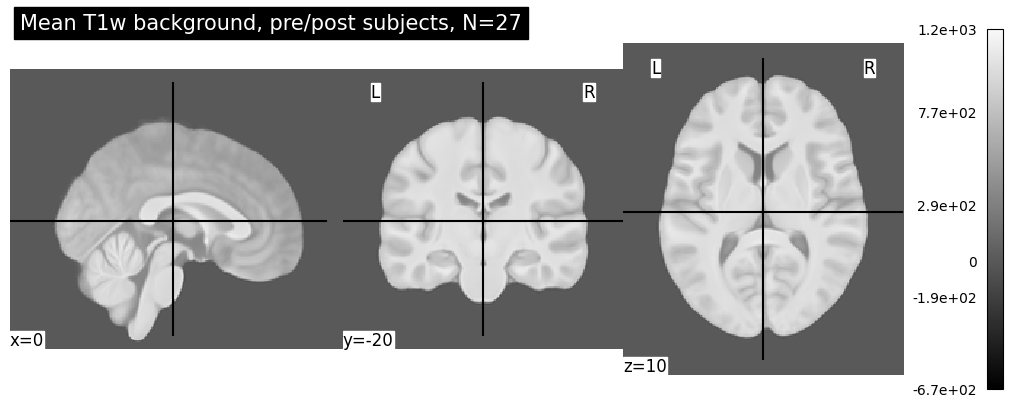

Saved QC figure:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/common_inputs/mean_anat/mean_T1w_prepost_N27_subjects_MNI152NLin2009cAsym_qc.png


In [9]:
# ============================================================
# Build mean subject T1w anatomical background
# Robust recursive fMRIPrep search
# ============================================================

import json
import numpy as np
import pandas as pd
from pathlib import Path

from nilearn.image import load_img, mean_img
from nilearn.plotting import plot_anat
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Output path for reusable mean T1w background
# ------------------------------------------------------------

MEAN_ANAT_DIR = DATA_DIR / "processed" / "common_inputs" / "mean_anat"
MEAN_ANAT_DIR.mkdir(parents=True, exist_ok=True)

MEAN_T1W_PATH = (
    MEAN_ANAT_DIR
    / f"mean_T1w_prepost_N{len(pre_post_subjects)}_subjects_{BOLD_SPACE}.nii.gz"
)

# ------------------------------------------------------------
# Robust subject-level T1w search
# ------------------------------------------------------------

def find_subject_t1w(sub, fmriprep_dir, bold_space):
    """Find the best available preprocessed T1w image for one subject."""
    
    sub_dir = Path(fmriprep_dir) / sub
    
    if not sub_dir.exists():
        return None, []
    
    patterns = [
        # Preferred: MNI-space T1w matching our BOLD space, allowing res/acq/ses fields
        f"**/{sub}*space-{bold_space}*desc-preproc_T1w.nii.gz",
        
        # Slightly broader MNI-space fallback
        f"**/{sub}*space-*MNI*desc-preproc_T1w.nii.gz",
        
        # Native-space preprocessed T1w fallback
        f"**/{sub}*desc-preproc_T1w.nii.gz",
    ]
    
    all_candidates = []
    
    for pattern in patterns:
        candidates = sorted(sub_dir.glob(pattern))
        all_candidates.extend(candidates)
        
        if len(candidates) > 0:
            return candidates[0], sorted(set(all_candidates))
    
    return None, sorted(set(all_candidates))


t1_records = []
t1_paths = []

for sub in pre_post_subjects:
    selected_path, all_candidates = find_subject_t1w(
        sub=sub,
        fmriprep_dir=FMRIPREP_DIR,
        bold_space=BOLD_SPACE,
    )
    
    if selected_path is None:
        print(f"WARNING: no preprocessed T1w image found for {sub}")
        t1_records.append({
            "subject": sub,
            "selected_t1w_path": None,
            "n_candidates": 0,
            "all_candidates": "",
        })
    else:
        t1_paths.append(selected_path)
        t1_records.append({
            "subject": sub,
            "selected_t1w_path": str(selected_path),
            "n_candidates": len(all_candidates),
            "all_candidates": " | ".join(str(p) for p in all_candidates),
        })

t1_qc = pd.DataFrame(t1_records)

t1_qc_path = MEAN_ANAT_DIR / "mean_T1w_input_files_qc.csv"
t1_qc.to_csv(t1_qc_path, index=False)

display(t1_qc)

print(f"Found {len(t1_paths)} T1w images out of {len(pre_post_subjects)} subjects.")
print("QC table saved:")
print(t1_qc_path)

assert len(t1_paths) > 0, (
    "No T1w images found. Run the diagnostic cell below to inspect the fMRIPrep folder structure."
)

# ------------------------------------------------------------
# Compute mean T1w image
# ------------------------------------------------------------

if MEAN_T1W_PATH.exists():
    print("Mean T1w image already exists:")
    print(MEAN_T1W_PATH)
    mean_t1w_img = load_img(str(MEAN_T1W_PATH))
else:
    print("Computing mean T1w image...")
    
    mean_t1w_img = mean_img([str(path) for path in t1_paths])
    mean_t1w_img.to_filename(str(MEAN_T1W_PATH))
    
    print("Saved mean T1w image:")
    print(MEAN_T1W_PATH)

print("Mean T1w shape:", mean_t1w_img.shape)
print("Mean T1w path:", MEAN_T1W_PATH)

# ------------------------------------------------------------
# QC plot
# ------------------------------------------------------------

fig = plt.figure(figsize=(10, 4))

plot_anat(
    mean_t1w_img,
    display_mode="ortho",
    cut_coords=(0, -20, 10),
    title=f"Mean T1w background, pre/post subjects, N={len(t1_paths)}",
    black_bg=False,
    figure=fig,
)

MEAN_T1W_QC_FIG_PATH = (
    MEAN_ANAT_DIR
    / f"mean_T1w_prepost_N{len(t1_paths)}_subjects_{BOLD_SPACE}_qc.png"
)

fig.savefig(MEAN_T1W_QC_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved QC figure:")
print(MEAN_T1W_QC_FIG_PATH)

In [10]:
# ============================================================
# 8. Save restart manifest
# ============================================================

manifest = {
    "notebook": "00_prepare_common_inputs.ipynb",
    "project_root": str(PROJECT_ROOT),

    "created_outputs": {
        "subject_table": str(subject_table_path),
        "file_availability_qc": str(file_qc_path),
        "image_matching_qc": str(image_matching_qc_path),
        "viewing_item_labels": str(viewing_item_labels_path),
        "subject_label_count_qc": str(subject_common_qc_path),
        "mean_t1w_path": str(MEAN_T1W_PATH),
        "mean_t1w_qc_figure_path": str(MEAN_T1W_QC_FIG_PATH),
        "mean_t1w_input_files_qc_path": str(t1_qc_path),
    },

    "sessions": {
        "pre": PRE_SESSION,
        "post": POST_SESSION,
        "task": VIEWING_TASK,
        "run": VIEWING_RUN,
        "bold_space": BOLD_SPACE,
    },

    "subjects": {
        "primary_post_only": primary_subjects_final,
        "pre_post_N27": pre_post_subjects,
        "pre_post_no_high_motion_N25": pre_post_no_high_motion_subjects,
        "excluded_pre_post": EXCLUDED_PRE_POST_SUBJECTS,
        "high_motion": HIGH_MOTION_SUBJECTS,
    },

    "input_tables": {
        "analysis_subjects": str(analysis_subjects_path),
        "spatial_behavior": str(spatial_behavior_path),
        "post_glm_backbone": str(post_glm_backbone_path),
    },

    "filename_parsing": {
        "pattern": "<theme>_<item_id>_e<episode>_<checkpoint>_<r/nr>_<h/o>_v<version>_<old/new>",
        "example": "viking_4_e2_2_r_h_v4_old",
        "episode_token": "e2",
        "checkpoint_token": "2 immediately after episode token",
        "checkpoint_min": int(CHECKPOINT_MIN),
        "checkpoint_max": int(CHECKPOINT_MAX),
        "checkpoint_out_of": 16,
        "checkpoint_third_rule": CHECKPOINT_THIRD_RULE,
        "relevance_codes": {"r": "relevant", "nr": "irrelevant"},
        "category_codes": {"h": "human", "o": "object"},
    },

    "mean_anat": {
        "mean_t1w_path": str(MEAN_T1W_PATH),
        "mean_t1w_qc_figure_path": str(MEAN_T1W_QC_FIG_PATH),
        "mean_t1w_input_files_qc_path": str(t1_qc_path),
        "n_subjects_in_mean_t1w": int(len(t1_paths)),
        "bold_space": BOLD_SPACE,
        "description": (
            "Mean fMRIPrep preprocessed T1w image in MNI space, computed across "
            "the final N=27 pre/post viewing subjects. Intended as a clean anatomical "
            "background for plotting group-level statistical maps in later notebooks."
        ),
    },
}

manifest_path = COMMON_MANIFEST_DIR / "common_inputs_manifest.json"

with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print("Saved manifest:", manifest_path)
print("\nReady for cleaned GLM notebooks.")

Saved manifest: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/common_inputs/restart/common_inputs_manifest.json

Ready for cleaned GLM notebooks.


## Outputs to reuse in later notebooks

The later notebooks should start by loading the common-inputs manifest created here:

```python
manifest_path = (
    DATA_DIR
    / "processed"
    / "common_inputs"
    / "restart"
    / "common_inputs_manifest.json"
)

with open(manifest_path, "r") as f:
    manifest = json.load(f)

## Outputs to reuse in later notebooks

The later notebooks should start by loading the common-inputs manifest created here:

```python
manifest_path = (
    DATA_DIR
    / "processed"
    / "common_inputs"
    / "restart"
    / "common_inputs_manifest.json"
)

with open(manifest_path, "r") as f:
    manifest = json.load(f)